# Análisis de Absentismo Laboral - RHHH

### Preguntas de negocio

> ¿Qué variables personales y laborales están más asociadas a niveles elevados de absentismo?  
> Cómo ajustamos nuestras políticas internas para abordar proactivamente estos perfiles de riesgo y reducir las ausencias?



### Justificación estadística

El EDA previo mostró una distribución asimétrica (a la derecha) de las horas de absentismo (`Absenteeism_hours`), con presencia de valores atípicos extremos. Por este motivo se utilizan pruebas no paramétricas para el análisis bivariante y un modelo de regresión Binomial Negativa para el análisis multivariable.

-**Análisis bivariantes**: permiten identificar qué características personales y laborales presentan asociación con el absentismo.  
-**La regresión Binomial Negativa**: evalúa el efecto conjunto de estas variables controlando el resto de factores.

Los resultados no deben interpretarse como relaciones causales.

### Metodología

1. Se hace agregacióon por empleado.
2. Se utilizan pruebas no paramétricas para el análisis bivariante.
    - Correlaciones de Spearman (variables numéricas).
    - Mann-Whitney (variables binarias).
    - Kruskal-Wallis (variables categóricas).
5. Comprovación de sobredispersión antes del modelo.
6. Modelo de regressió Binomial Negativa.

## 1. Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

import os
from dotenv import load_dotenv

## 2. Carga de datos

In [21]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-06.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados correctamente desde el archivo CSV.'

**Base para el modelo**. Para construir el conjunto de datos a nivel de empleado, se agregaron las horas de absentismo mediante la suma, ya que representan el resultado acumulado del período analizado. Las variables personales y sociodemográficas, al ser características estables del empleado, se conservaron utilizando el primer valor registrado (first). En cambio, aquellas variables que pueden variar entre episodios, como la carga media de trabajo, se resumieron mediante la media (mean), con el objetivo de representar la exposición habitual de cada empleado durante el período de estudio (1 año).

In [22]:
# Base para el modelo
df_modelo = (
    df.groupby("ID_Employee")
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
        Age=("Age", "first"),
        Education=("Education", "first"),
        Son=("Son", "first"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Pet=("Pet", "first"),
        Body_Mass_Index=("Body_Mass_Index", "first"),
        Transportation_Expense=("Transportation_Expense", "first"),
        Distance_Residence_Work=("Distance_Residence_Work", "first"),
        Service_Time=("Service_Time", "first"),
        Work_load_Average_Day=("Work_load_Average_Day", "mean"),
        Hit_Target=("Hit_Target", "mean"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
    .reset_index()
)

print(df_modelo.shape)
df_modelo.head()

(136, 15)


,ID_Employee,Total_Horas_Absentismo,Age,Education,Son,Social_Drinker,Social_Smoker,Pet,Body_Mass_Index,Transportation_Expense,Distance_Residence_Work,Service_Time,Work_load_Average_Day,Hit_Target,Disciplinary_Failure
0,1,121,37,3,1,0,0,1,29,235,11,14,262.894478,95.173913,1
1,2,25,48,1,1,0,1,5,33,235,29,12,241.597000,93.333333,1
2,3,444,38,1,0,1,0,0,31,179,51,18,264.747216,94.762887,1
3,4,0,40,1,1,1,0,8,34,118,14,13,271.219000,95.000000,0
4,5,102,43,1,1,1,0,0,38,235,20,13,266.741389,91.722222,1


El análisis se realiza a nivel de empleado (136 observaciones), agregando las horas totales de absentismo por trabajador. Así se garantiza la independencia de las observaciones y se puede responder a la pregunta sobre qué perfiles presentan un mayor riesgo de absentismo.

## 3. ANáLISIS

### 3.1 Test individuales no paramétricos

In [23]:
print("--- 1: ANÁLISIS BIVARIANTE ---")
print("Unidad: horas por empleado")

# A. Correlación de Spearman con las horas totales de absentismo
vars_numericas = [
    "Son",
    "Age",
    "Service_Time",
    "Transportation_Expense",
    "Distance_Residence_Work",
    "Body_Mass_Index",
    "Work_load_Average_Day",
    "Hit_Target",
    "Pet",
]

print("\n[Correlación de Spearman con Total_Horas_Absentismo]")

for var in vars_numericas:
    r, p_val = stats.spearmanr(df_modelo[var], df_modelo["Total_Horas_Absentismo"])

    if p_val < 0.05:
        if abs(r) < 0.20:
            fuerza = "Muy débil"
        elif abs(r) < 0.40:
            fuerza = "Débil"
        elif abs(r) < 0.60:
            fuerza = "Moderada"
        elif abs(r) < 0.80:
            fuerza = "Fuerte"
        else:
            fuerza = "Muy fuerte"

        estado = f"Significativa ({fuerza})"
    else:
        estado = "No significativa"

    print(
        f"Variable: {var:25} | r = {r:6.3f} | p-valor = {p_val:.4f} -> {estado}"
    )


# B. Test de Mann-Whitney U para variables binarias

vars_binarias = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure",
]

print("\n[Test de Mann-Whitney U para variables binarias]")

for var in vars_binarias:

    grupo_0 = df_modelo[df_modelo[var] == 0]["Total_Horas_Absentismo"]
    grupo_1 = df_modelo[df_modelo[var] == 1]["Total_Horas_Absentismo"]

    stat, p_val = stats.mannwhitneyu(
        grupo_0,
        grupo_1,
        alternative="two-sided"
    )

    med_0 = grupo_0.median()
    med_1 = grupo_1.median()

    if p_val < 0.05:
        estado = "Diferencia significativa (perfil de riesgo)"
    else:
        estado = "No significativa"

    print(
        f"Variable: {var:22} | p-valor = {p_val:.4f} | "
        f"Mediana(0): {med_0:.1f} | Mediana(1): {med_1:.1f} -> {estado}"
    )

--- 1: ANÁLISIS BIVARIANTE ---
Unidad: horas por empleado

[Correlación de Spearman con Total_Horas_Absentismo]
Variable: Son                       | r =  0.191 | p-valor = 0.0256 -> Significativa (Muy débil)
Variable: Age                       | r = -0.059 | p-valor = 0.4955 -> No significativa
Variable: Service_Time              | r = -0.048 | p-valor = 0.5799 -> No significativa
Variable: Transportation_Expense    | r =  0.273 | p-valor = 0.0013 -> Significativa (Débil)
Variable: Distance_Residence_Work   | r = -0.106 | p-valor = 0.2185 -> No significativa
Variable: Body_Mass_Index           | r = -0.142 | p-valor = 0.0987 -> No significativa
Variable: Work_load_Average_Day     | r =  0.210 | p-valor = 0.0143 -> Significativa (Débil)
Variable: Hit_Target                | r = -0.089 | p-valor = 0.3015 -> No significativa
Variable: Pet                       | r =  0.051 | p-valor = 0.5532 -> No significativa

[Test de Mann-Whitney U para variables binarias]
Variable: Social_Drinker   

### 3.2 Regresión Binomial Negativa

La regresión Binomial Negativa permite evaluar el efecto conjunto de todas las variables incluidas en el análisis. A diferencia del análisis bivariante, los coeficientes estiman la asociación de cada variable controlando por el efecto del resto de predictores.

> Comprobación de sobredispersión previa al modelo  
Antes de usar un modelo multivariable comprovamos si sobredispersión (VARIANZA > MEDIA/PROMEDIO), lo que justificará el uso de la regresión Binomial Negativa frente a Poisson. 

In [5]:
mean_abs = df_modelo['Total_Horas_Absentismo'].mean()
var_abs = df_modelo['Total_Horas_Absentismo'].var()

print(f"Media: {mean_abs:.2f}")
print(f"Varianza: {var_abs:.2f}")

if var_abs > mean_abs:
    print("Existe evidencia de sobredispersión. La regresión Binomial Negativa es adecuada.")
else:
    print("No se aprecia sobredispersión importante.")


Media: 42.62
Varianza: 9062.96
Existe evidencia de sobredispersión. La regresión Binomial Negativa es adecuada.


> La varianza de las horas de absentismo es superior a la media, lo que indica la presencia de sobredispersión. En este caso, la regresión de Poisson puede infravalorar la variabilidad de los datos. Por ello se utiliza una regresión Binomial Negativa, más adecuada para este tipo de distribución.

In [24]:
# Modelo Regresión Binomial Negativa


print("--- 2: ANÁLISIS MULTIVARIANTE ---")
print("Modelo: Regresión Binomial Negativa")
print("Unidad: horas por empleado")

formula = (
    "Total_Horas_Absentismo ~ Son + Age + Service_Time + "
    "Transportation_Expense + Distance_Residence_Work + "
    "Body_Mass_Index + Work_load_Average_Day + Hit_Target + "
    "Pet + C(Social_Drinker) + C(Social_Smoker) + "
    "C(Education)"
)

modelo_nb = smf.glm(
    formula=formula,
    data=df_modelo,
    family=sm.families.NegativeBinomial()
).fit()

print(modelo_nb.summary())

--- 2: ANÁLISIS MULTIVARIANTE ---
Modelo: Regresión Binomial Negativa
Unidad: horas por empleado
                   Generalized Linear Model Regression Results                    
Dep. Variable:     Total_Horas_Absentismo   No. Observations:                  136
Model:                                GLM   Df Residuals:                      121
Model Family:            NegativeBinomial   Df Model:                           14
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -633.56
Date:                   ju., 09 jul. 2026   Deviance:                       410.98
Time:                            12:46:03   Pearson chi2:                     652.
No. Iterations:                        38   Pseudo R-squ. (CS):             0.1903
Covariance Type:                nonrobust                                         
                              coef    std err          z      P>|z|      

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [25]:
irr = np.exp(modelo_nb.params)

display(
    pd.DataFrame({
        "Coeficiente": modelo_nb.params,
        "IRR": irr,
        "p-value": modelo_nb.pvalues
    })
)

,Coeficiente,IRR,p-value
Intercept,18.056013,6.944271e+07,5.649130e-07
C(Social_Drinker)[T.1],0.171761,1.187393e+00,4.500742e-01
C(Social_Smoker)[T.1],-0.895921,4.082315e-01,4.680042e-03
C(Education)[T.2],0.314064,1.368978e+00,4.124251e-01
C(Education)[T.3],-0.288605,7.493082e-01,4.205559e-01
C(Education)[T.4],-1.131859,3.224333e-01,1.495595e-01
Son,0.180834,1.198216e+00,6.243535e-02
Age,0.001123,1.001124e+00,9.499848e-01
Service_Time,0.035357,1.035990e+00,3.060821e-01
Transportation_Expense,0.000211,1.000211e+00,8.853228e-01


La significación estadística indica qué variables mantienen una asociación con el absentismo tras controlar por el resto de variables incluidas en el modelo.

- ### Importancia relativa de las variables 


In [28]:
# Resultados del modelo
resultados = pd.DataFrame({
    "Variable": modelo_nb.params.index,
    "Coeficiente": modelo_nb.params.values,
    "P_Value": modelo_nb.pvalues.values
})

# Quitamos intercepto
resultados = resultados[resultados["Variable"] != "Intercept"].copy()

# Convertimos coeficientes a IRR y efecto porcentual
resultados["IRR"] = np.exp(resultados["Coeficiente"])
resultados["Efecto_%"] = (resultados["IRR"] - 1) * 100

# Limpiar nombres para visualización
resultados["Variable_Limpia"] = (
    resultados["Variable"]
    .str.replace("C(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("[T.", " = ", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Nos quedamos solo con variables que aumentan las horas
variables_influyentes = (
    resultados[resultados["Efecto_%"] > 0]
    .sort_values("Efecto_%", ascending=False)
    .copy()
)

variables_influyentes[[
    "Variable_Limpia",
    "Efecto_%",
    "P_Value",
    "IRR"
]]

,Variable_Limpia,Efecto_%,P_Value,IRR
3,Education = 2,36.897774,0.412425,1.368978
6,Son,19.821633,0.062435,1.198216
1,Social Drinker = 1,18.739347,0.450074,1.187393
8,Service Time,3.598983,0.306082,1.035990
14,Pet,0.272936,0.969418,1.002729
12,Work load Average Day,0.228300,0.430607,1.002283
7,Age,0.112406,0.949985,1.001124
9,Transportation Expense,0.021106,0.885323,1.000211


- Variables mas influyentes

In [30]:
display(
    resultados.sort_values(
        "P_Value"
    )[
        [
            "Variable_Limpia",
            "IRR",
            "Efecto_%",
            "P_Value"
        ]
    ]
)

,Variable_Limpia,IRR,Efecto_%,P_Value
13,Hit Target,0.864996,-13.500409,0.000015
2,Social Smoker = 1,0.408232,-59.176849,0.004680
11,Body Mass Index,0.942088,-5.791162,0.035065
6,Son,1.198216,19.821633,0.062435
10,Distance Residence Work,0.987456,-1.254373,0.105634
5,Education = 4,0.322433,-67.756667,0.149559
8,Service Time,1.035990,3.598983,0.306082
3,Education = 2,1.368978,36.897774,0.412425
4,Education = 3,0.749308,-25.069184,0.420556
12,Work load Average Day,1.002283,0.228300,0.430607


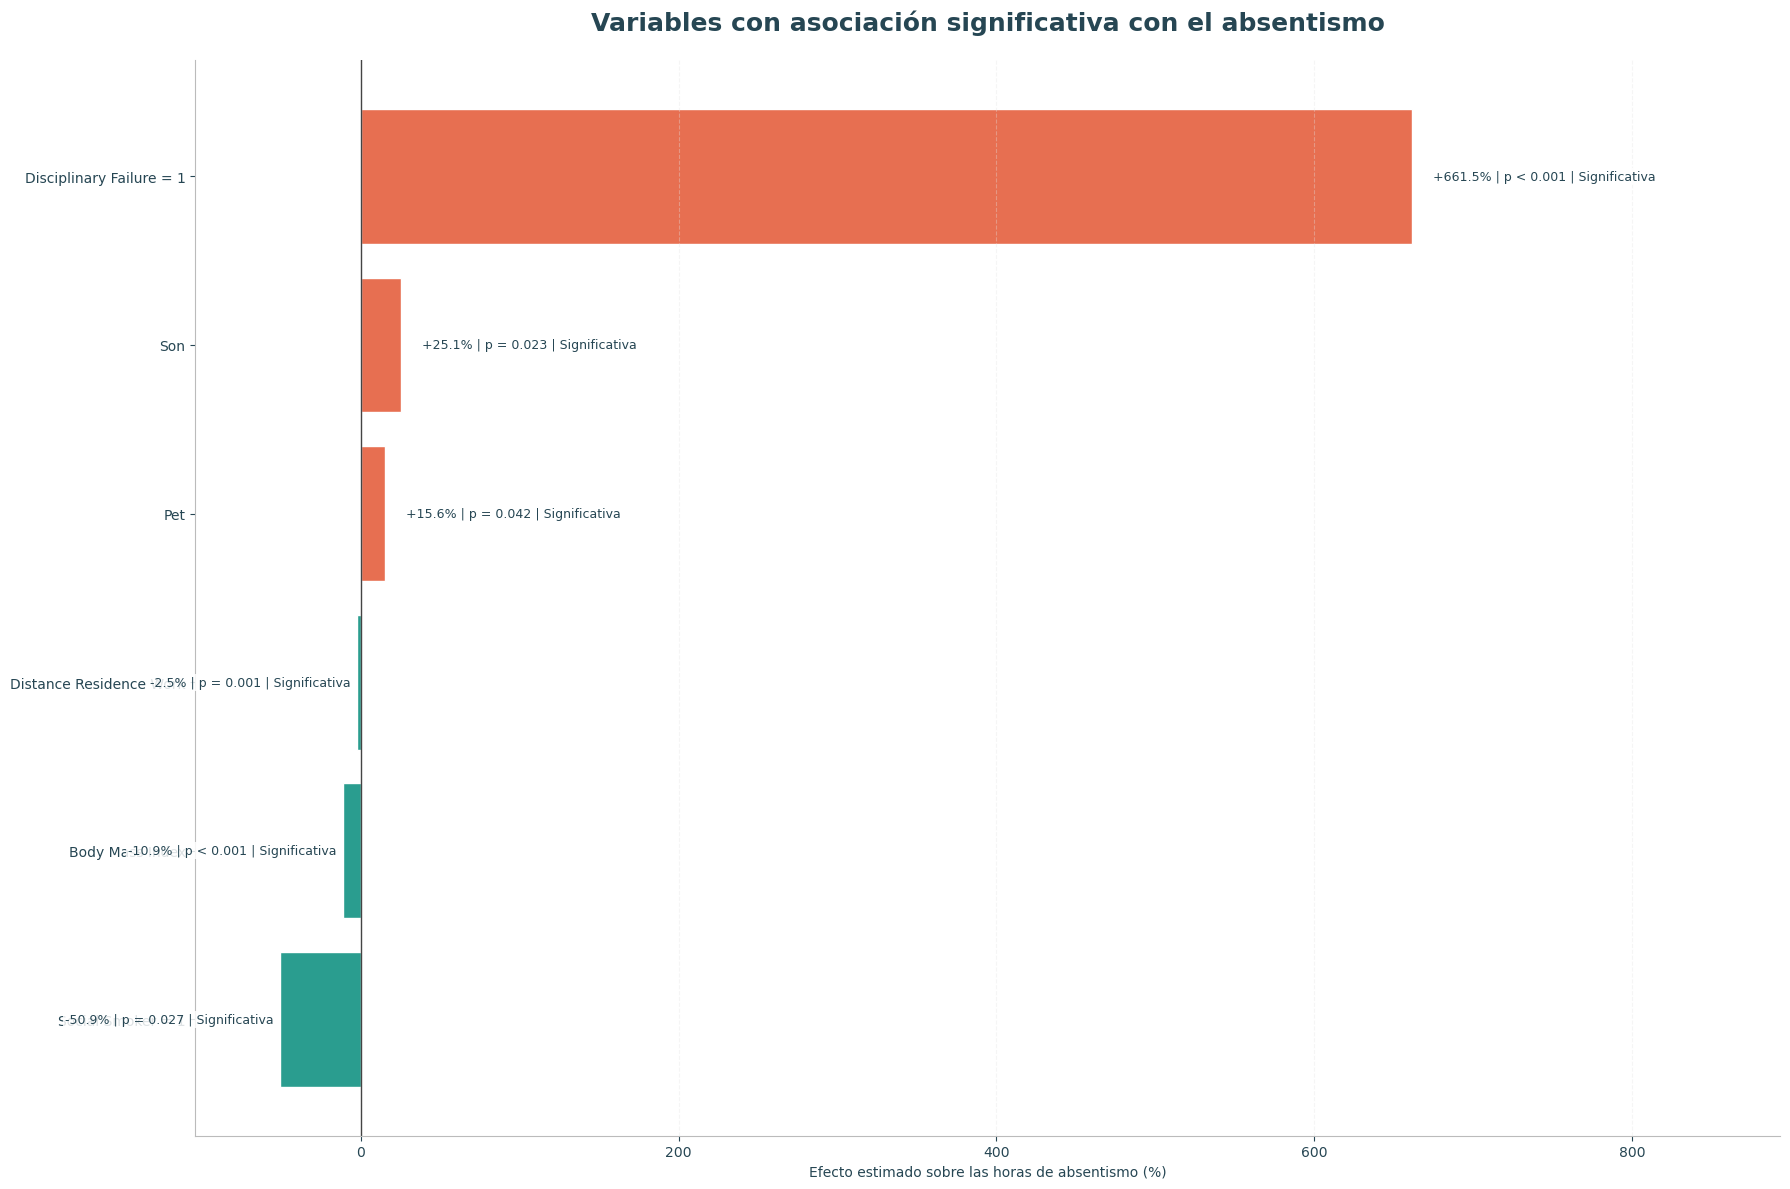

In [ ]:
# Variables con asociación significativa con el absentismo

mas_influyentes = (
    resultados[resultados["P_Value"] < 0.05]
    .sort_values("Impacto_Abs", ascending=False)
)

mas_influyentes = mas_influyentes.sort_values("Efecto_%")

color_aumenta = "#E76F51"
color_reduce = "#2A9D8F"
color_texto = "#264653"
color_grid = "#E5E4E4"

colores = [
    color_aumenta if efecto > 0 else color_reduce
    for efecto in mas_influyentes["Efecto_%"]
]

fig, ax = plt.subplots(figsize=(18, 12))

bars = ax.barh(
    mas_influyentes["Variable_Limpia"],
    mas_influyentes["Efecto_%"],
    color=colores,
    edgecolor="white",
    linewidth=1
)

ax.axvline(0, color="#444444", linewidth=1)

ax.set_title(
    "Variables con asociación significativa con el absentismo",
    fontsize=18,
    fontweight="bold",
    color=color_texto,
    pad=22
)

ax.set_xlabel("Efecto estimado sobre las horas de absentismo (%)", color=color_texto)
ax.grid(axis="x", linestyle="--", alpha=0.35, color=color_grid)

# Límites con espacio extra para etiquetas
min_x = mas_influyentes["Efecto_%"].min()
max_x = mas_influyentes["Efecto_%"].max()

ax.set_xlim(min_x - abs(min_x) * 0.65 - 20, max_x * 1.35)

# Etiquetas
for bar, efecto, p_label, sig in zip(
    bars,
    mas_influyentes["Efecto_%"],
    mas_influyentes["P_Label"],
    mas_influyentes["Significancia"]
):
    label = f"{efecto:+.1f}% | {p_label} | {sig}"
    
    if efecto >= 0:
        x_pos = efecto + max_x * 0.02
        ha = "left"
    else:
        x_pos = efecto - abs(min_x) * 0.08
        ha = "right"
    
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha=ha,
        fontsize=9,
        color=color_texto,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.5
        )
    )

# Limpieza visual
ax.tick_params(axis="x", colors=color_texto)
ax.tick_params(axis="y", colors=color_texto, labelsize=10)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#BBBBBB")
ax.spines["bottom"].set_color("#BBBBBB")

plt.tight_layout()
plt.show()

## Conclusiones


La regresión Binomial Negativa permitió analizar el efecto conjunto de las variables personales y laborales sobre las horas de absentismo.

Los resultados muestran que el x, x, x presentan una asociación positiva y estadísticamente significativa con el absentismo. En cambio, x, x, x muestran una asociación negativa.

Por otro lado, variables como x, x, x, no presentan una asociación estadísticamente significativa en este modelo.

Estos resultados permiten identificar perfiles con mayor riesgo de absentismo y pueden servir de apoyo para diseñar políticas preventivas y acciones de bienestar dirigidas a los colectivos más vulnerables.